In [ ]:
import pandas as pd

df = pd.read_csv('/content/spam.csv', encoding='latin1')

In [ ]:
df = df[['v1','v2']]

In [ ]:
df.columns = ['label','message']

In [ ]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.isnull().sum()

,0
label,0
message,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['label'] = encoder.fit_transform(df['label'])

In [ ]:
!pip install nltk

In [ ]:
import nltk
import string

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

nltk.download('punkt')
nltk.download('stopwords')

ps = PorterStemmer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
def transform_text(text):

    text = text.lower()

    words = nltk.word_tokenize(text)

    y = []

    for i in words:
        if i.isalnum():
            y.append(i)

    words = y[:]
    y.clear()

    for i in words:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    words = y[:]
    y.clear()

    for i in words:
        y.append(ps.stem(i))

    return " ".join(y)

In [ ]:
df['transformed_text'] = df['message'].apply(transform_text)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['transformed_text']).toarray()

y = df['label']

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train,y_train)

MultinomialNB()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision :", precision_score(y_test,y_pred))

print(confusion_matrix(y_test,y_pred))

Accuracy : 0.9775784753363229
Precision : 1.0
[[965   0]
 [ 25 125]]


In [ ]:
msg = "Congratulations! You won 10000 rupees"

transformed = transform_text(msg)

vector = tfidf.transform([transformed])

prediction = model.predict(vector)

if prediction[0] == 1:
    print("Spam")
else:
    print("Ham")

Ham


In [ ]:
import pickle

pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(model,open('spam_model.pkl','wb'))

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9775784753363229
Precision: 1.0
Recall: 0.8333333333333334
F1 Score: 0.9090909090909091


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[965   0]
 [ 25 125]]


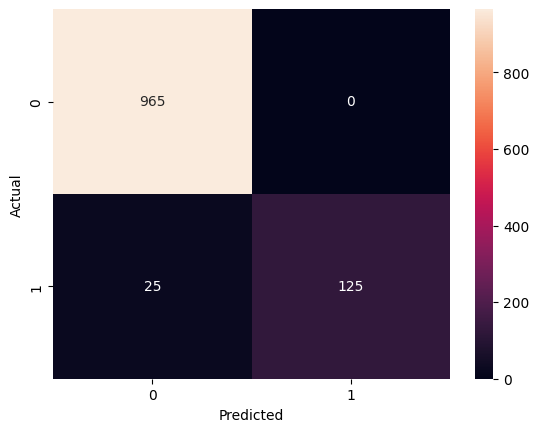

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
test_messages = [
    "Congratulations! You won a free iPhone",
    "Can we meet tomorrow?",
    "Claim your cash prize now",
    "How are you doing today?"
]

for msg in test_messages:
    transformed = transform_text(msg)
    vector = tfidf.transform([transformed])
    prediction = model.predict(vector)

    print(msg, "->", "Spam" if prediction[0] == 1 else "Ham")

Congratulations! You won a free iPhone -> Spam
Can we meet tomorrow? -> Ham
Claim your cash prize now -> Spam
How are you doing today? -> Ham
